<a href="https://colab.research.google.com/github/vu1f2425010-cpu/yuva-/blob/main/week_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zip mil gaya: /archive.zip
Zip ke andar: ['netflix_titles.csv']

Shape: (8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  

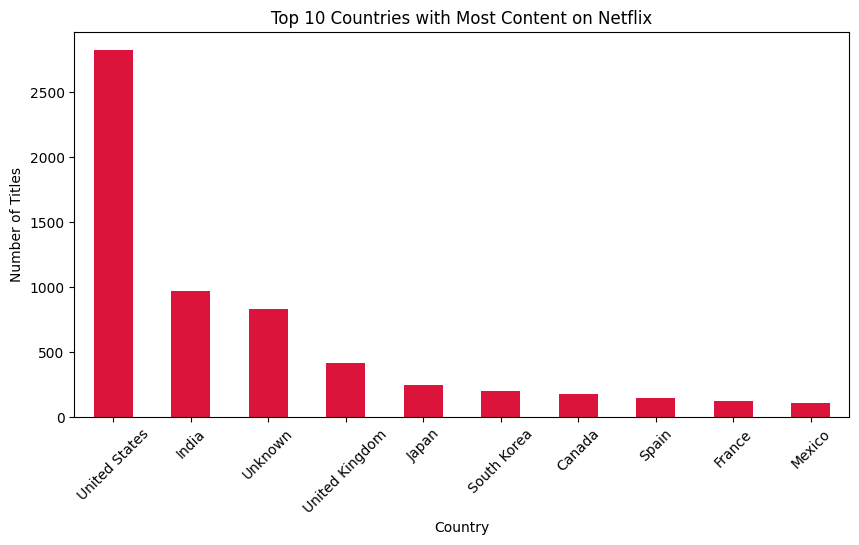

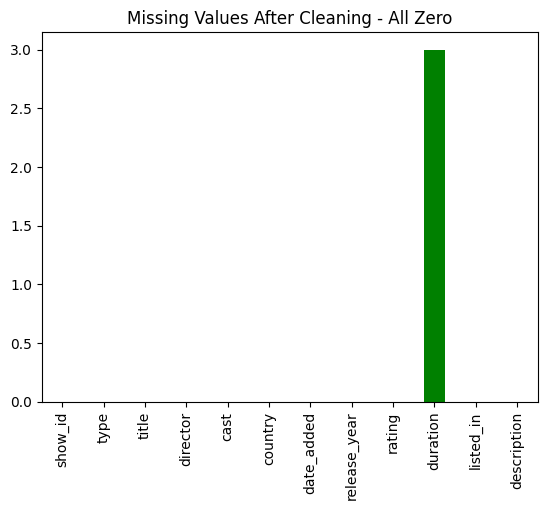

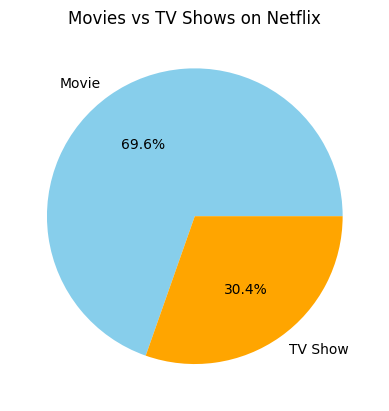

In [ ]:
# WEEK 1 FINAL - 100% Working Code (archive.zip se)

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

# File kaha hai dhundo aur extract karo
if os.path.exists('/archive.zip'):
    zip_path = '/archive.zip'
elif os.path.exists('/content/archive.zip'):
    zip_path = '/content/archive.zip'
else:
    zip_path = 'archive.zip'

print(f"Zip mil gaya: {zip_path}")

with zipfile.ZipFile(zip_path, 'r') as z:
    # andar ka csv naam kya hai check karo
    print("Zip ke andar:", z.namelist())
    z.extractall('/content/')

# Ab csv load karo
df = pd.read_csv('/content/netflix_titles.csv')
print("\nShape:", df.shape)
print(df.head())

print("\nMissing Before:", df.isnull().sum().to_dict())

# Cleaning
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df.drop_duplicates(inplace=True)

print("\nCleaning ke baad Shape:", df.shape)

import matplotlib.pyplot as plt
import seaborn as sns

# Graph 3 - Top 10 Countries with most content
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar', color='crimson')
plt.title('Top 10 Countries with Most Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

# Graph 1 - Missing values after cleaning
df.isnull().sum().plot(kind='bar', color='green')
plt.title('Missing Values After Cleaning - All Zero')
plt.show()

# Graph 2 - Movies vs TV Shows
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue','orange'])
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')
plt.show()